# Part 1

We import the `logins.json` file and create a timeseries visualization of logins at the given geographical location.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_json('logins.json')

## Initial EDA

In [3]:
df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [4]:
df.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


The data appears to be solid. There were no null values and there were a significant number of entries.

The data increases linearly in terms of time. There are a few light patterns visible in the line.

Let's break the data into fifteen-minute increments.

<Axes: title={'center': 'Logins'}>

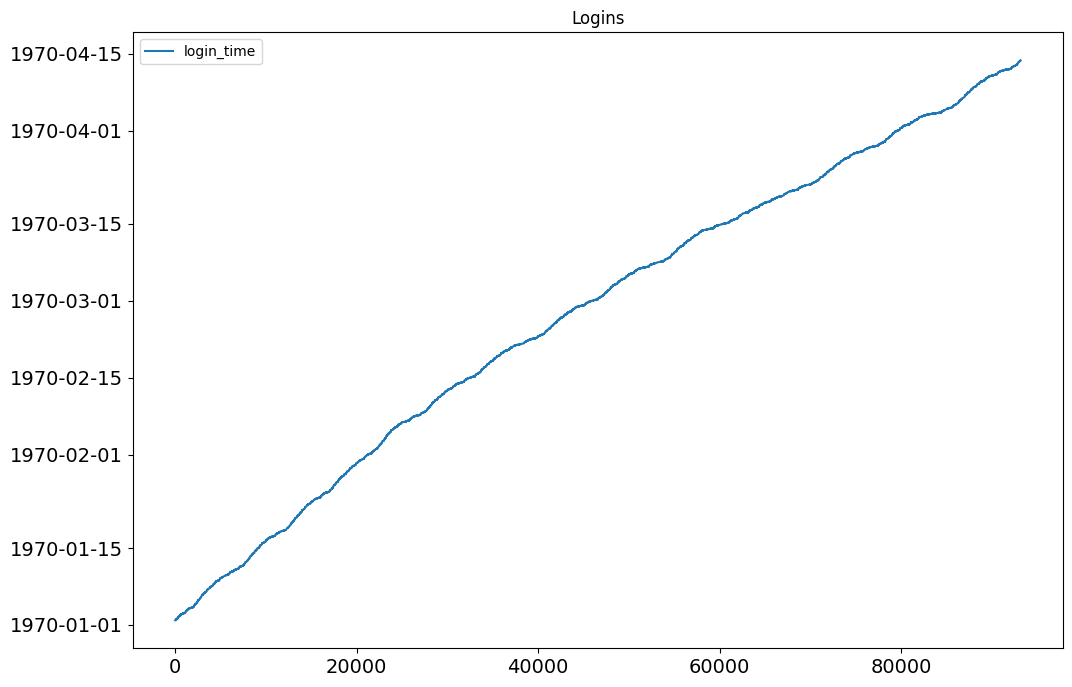

In [6]:
df.plot(figsize=(12,8), title='Logins', fontsize=14)

## Breaking into 15 Minute Increments

In [7]:
df['15min_inc'] = df['login_time'].dt.floor('15min')

In [9]:
df.head(10)

,login_time,15min_inc
0,1970-01-01 20:13:18,1970-01-01 20:00:00
1,1970-01-01 20:16:10,1970-01-01 20:15:00
2,1970-01-01 20:16:37,1970-01-01 20:15:00
3,1970-01-01 20:16:36,1970-01-01 20:15:00
4,1970-01-01 20:26:21,1970-01-01 20:15:00
5,1970-01-01 20:21:41,1970-01-01 20:15:00
6,1970-01-01 20:12:16,1970-01-01 20:00:00
7,1970-01-01 20:35:47,1970-01-01 20:30:00
8,1970-01-01 20:35:38,1970-01-01 20:30:00
9,1970-01-01 20:47:52,1970-01-01 20:45:00


In [12]:
df['month'] = df['login_time'].dt.month

In [14]:
df['day_name'] = df['login_time'].dt.day_name()

In [16]:
df['time_15_min_inc'] = df['15min_inc'].dt.time

In [58]:
bins = pd.date_range(start="00:00", end="23:45", freq="15min").time

In [59]:
type(bins)

numpy.ndarray

In [60]:
len(bins)

96

In [61]:
type(df['time_15_min_inc'])

pandas.core.series.Series

In [64]:
type(df['time_15_min_inc'].iloc[0].strftime("%H:%M"))

str

In [66]:
df['time_15_min_inc'].iloc[0].strftime("%H:%M")

'20:00'

In [72]:
df['15min_as_str'] = df['time_15_min_inc'].apply(lambda x: x.strftime('%H:%M'))

In [73]:
df['15min_as_str'].head(2)

0    20:00
1    20:15
Name: 15min_as_str, dtype: object

In [74]:
type(df['15min_as_str'].iloc[0])

str

In [78]:
counts_15min = df['15min_as_str'].value_counts().sort_index()

In [79]:
counts_15min

15min_as_str
00:00    1439
00:15    1547
00:30    1525
00:45    1482
01:00    1549
         ... 
22:45    1637
23:00    1573
23:15    1552
23:30    1456
23:45    1477
Name: count, Length: 96, dtype: int64

In [34]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [53]:
time_of_day_counts = df['time_15_min_inc'].value_counts().sort_index()

TypeError: the dtypes of parameters x (object) and width (float64) are incompatible

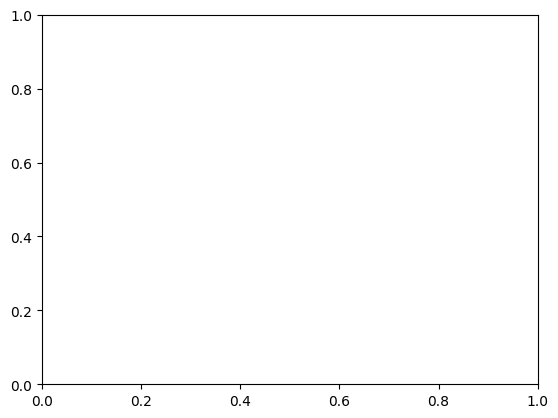

In [54]:
plt.bar(x=pd.Series(bins), height=time_of_day_counts, edgecolor='black', align='center')

In [ ]:
fig, ax = plt.subplots(2, 1)

ax[0].bar(